# 🎬 Tugas 2: Information Retrieval - Text Clustering & Classification pada IMDB Dataset

**Mata Kuliah:** Information Retrieval (Week 4)  
**Program Studi:** Sains Data - UPN "Veteran" Jawa Timur  
**Topik:** Clustering dan Klasifikasi Teks Menggunakan Representasi TF-IDF (*Term Frequency - Inverse Document Frequency*)  
**Dataset:** `IMDB Dataset.csv` (Ulasan Film Positif & Negatif)  
**Output:** Seluruh hasil pemrosesan data, prediksi cluster, klasifikasi, dan metrik evaluasi otomatis disimpan ke dalam folder **`hasil/`**.  
**Prinsip Utama:** *"Dokumen teks diubah menjadi vektor numerik sparse TF-IDF, lalu model menemukan kelompok (Clustering) atau memprediksi kategori (Classification)."*

---

### 🎯 Alur Pipeline & Ekspor Hasil:
1. **Pemuatan & Pembersihan Teks:** Membersihkan tag HTML, URL, dan karakter non-alfanumerik.
2. **Representasi TF-IDF Sparse:** Mentransformasikan ulasan teks menjadi matriks bobot numerik (`sublinear_tf=True`, `norm='l2'`).
3. **Document Clustering (Unsupervised):** Mengelompokkan dokumen menggunakan algoritma **K-Means** ($k=2$), evaluasi 4 pilar (Silhouette, Inertia, ARI, Top Terms), dan visualisasi 2D TruncatedSVD.
4. **Document Classification (Supervised):** Membangun **Pipeline Scikit-Learn** (`TfidfVectorizer` + `LogisticRegression`), evaluasi *Classification Report*, *Confusion Matrix*, dan inferensi.
5. **📁 Ekspor Hasil ke Folder `hasil/`:**
   - `hasil/processed_imdb_dataset.csv`: Dataset lengkap beserta kolom teks bersih, cluster K-Means, prediksi kelas, dan probabilitas.
   - `hasil/top_terms_per_cluster.csv`: Daftar term/kata kunci paling representatif untuk setiap cluster centroid.
   - `hasil/evaluation_metrics.txt`: Ringkasan metrik evaluasi numerik (Silhouette, ARI, Inertia, Akurasi, F1-Score).

## ⚙️ 0. Environment Setup & Inisialisasi Folder Hasil
Mengimpor pustaka penting dan membuat direktori `hasil/` untuk menyimpan data output.

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-Learn Modules
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD

# Membuat folder 'hasil' jika belum ada
OUTPUT_DIR = "hasil"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Konfigurasi visualisasi
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 150)

print(f"✅ Lingkungan siap! Folder penyimpanan: '{os.path.abspath(OUTPUT_DIR)}'")

✅ Lingkungan siap! Folder penyimpanan: 'd:\Github\kuliah\semester 7\Information Retrieval B\tugas 2\dengan dataset\hasil'


## 📂 1. Pemuatan & Eksplorasi Dataset IMDB
Membaca file `IMDB Dataset.csv` yang berisi ulasan film beserta label sentimen (`positive` / `negative`).

In [2]:
# Memuat dataset dari folder lokal
csv_path = "IMDB Dataset.csv"
if not os.path.exists(csv_path):
    csv_path = os.path.join("dengan dataset", "IMDB Dataset.csv")

df_raw = pd.read_csv(csv_path)
print(f"📊 Total Baris & Kolom Dataset: {df_raw.shape}")
print("\nDistribusi Sentimen Asli:")
print(df_raw['sentiment'].value_counts())

# Tampilkan 5 sampel ulasan pertama
df_raw.head()

📊 Total Baris & Kolom Dataset: (50000, 2)

Distribusi Sentimen Asli:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened ...",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometim...",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted ...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />Thi...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. Thi...",positive


### 🧹 1.1 Pembersihan Teks (Text Cleaning) & Sampling Data

In [3]:
def clean_review(text):
    if not isinstance(text, str):
        return ""
    # Hapus tag HTML
    text = re.sub(r"<[^>]+>", " ", text)
    # Hapus URL
    text = re.sub(r"http\S+|www\S+", "", text)
    # Hapus karakter non-alfanumerik
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    # Normalisasi spasi
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Ambil sampel representatif terstratifikasi (5.000 ulasan seimbang)
SAMPLE_SIZE = 5000
df = (
    df_raw.groupby('sentiment', group_keys=False)
    .apply(lambda x: x.sample(n=SAMPLE_SIZE // 2, random_state=42))
    .reset_index(drop=True)
)

df['cleaned_review'] = df['review'].apply(clean_review)
print(f"✅ Dataset Siap Diproses: {len(df)} ulasan ({df['sentiment'].value_counts().to_dict()})")
df[['sentiment', 'cleaned_review']].head()

C:\Users\caezarlov\AppData\Local\Temp\ipykernel_8872\2610022717.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=SAMPLE_SIZE // 2, random_state=42))


✅ Dataset Siap Diproses: 5000 ulasan ({'negative': 2500, 'positive': 2500})


,sentiment,cleaned_review
0,negative,I was looking forward to seeing Bruce Willis in this especially since I remember being mesmerised by the original when I was young This movie is a...
1,negative,Bugs Bunny accidentally ends up at the South Pole while trying to vacation in Florida Where he meets a little penquin which he tries to save from ...
2,negative,I find it difficult to comprehend what makes viewer s feel this is a powerful movie I would guess that the main intention of this film would be a ...
3,negative,It s been said several times not least by me that watching an Eric Rohmer film is like watching paint dry it seems that Monsieur Rohmer resents th...
4,negative,New rule Nobody is allowed to make any more Zombie movies unless they actually come up with an original idea Sadly this movie doesn t They have th...


## 🧮 2. Representasi Matriks TF-IDF yang Sparse (Slide 06)

$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$

In [4]:
tfidf = TfidfVectorizer(
    lowercase=True,
    sublinear_tf=True,
    norm="l2",
    stop_words='english',
    max_features=2500,
    min_df=3
)

docs = df['cleaned_review'].tolist()
labels = df['sentiment'].tolist()

X_tfidf = tfidf.fit_transform(docs)
feature_names = tfidf.get_feature_names_out()

n_docs, n_terms = X_tfidf.shape
density = (X_tfidf.nnz / (n_docs * n_terms)) * 100

print(f"📊 Dimensi Matriks TF-IDF : {X_tfidf.shape} (Jumlah Dokumen={n_docs}, Kosakata Fitur={n_terms})")
print(f"🔹 Kepadatan Matriks (Density) : {density:.2f}% (Tingkat Sparsity: {100 - density:.2f}% sel bernilai 0)")

📊 Dimensi Matriks TF-IDF : (5000, 2500) (Jumlah Dokumen=5000, Kosakata Fitur=2500)
🔹 Kepadatan Matriks (Density) : 2.40% (Tingkat Sparsity: 97.60% sel bernilai 0)


### 📋 Contoh Tabel Subset Matriks TF-IDF yang Sparse

=== Matriks TF-IDF yang Sparse (10 Dokumen Pertama vs Kata Sentimen) ===


,great,excellent,masterpiece,bad,terrible,worst,acting,story
Review_1 (neg),0,0,0,0,0,0,0,0.09
Review_2 (neg),0.09,0,0,0,0,0,0,0
Review_3 (neg),0,0,0,0,0,0,0.08,0.07
Review_4 (neg),0,0,0,0,0,0,0,0.07
Review_5 (neg),0,0,0,0,0,0,0,0
Review_6 (neg),0,0,0,0,0,0,0,0
Review_7 (neg),0,0,0,0,0,0,0.09,0
Review_8 (neg),0,0,0,0,0,0,0,0
Review_9 (neg),0,0,0,0,0,0,0.07,0.06
Review_10 (neg),0,0,0,0,0,0,0.15,0


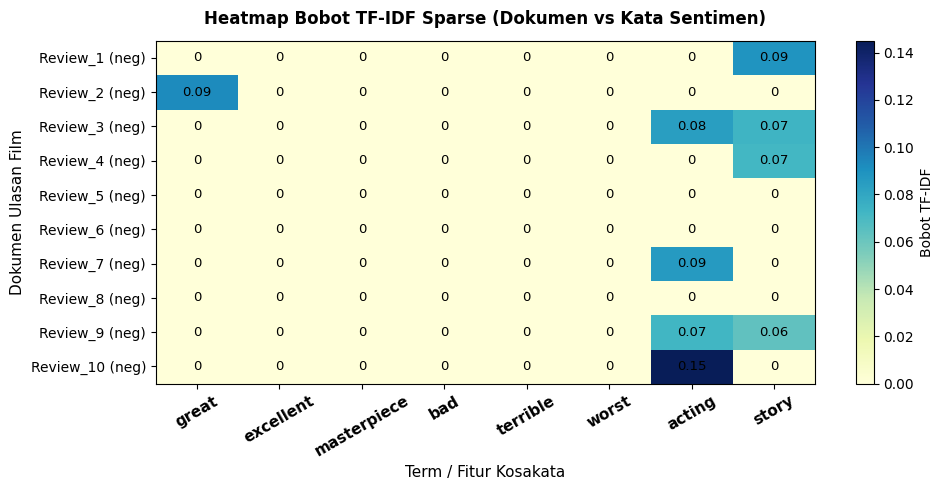

In [5]:
sample_terms = ['great', 'excellent', 'masterpiece', 'bad', 'terrible', 'worst', 'acting', 'story']
available_terms = [t for t in sample_terms if t in feature_names]

df_sparse_sample = pd.DataFrame(
    X_tfidf[:10].toarray(),
    index=[f"Review_{i+1} ({labels[i][:3]})" for i in range(10)],
    columns=feature_names
)[available_terms]

print("=== Matriks TF-IDF yang Sparse (10 Dokumen Pertama vs Kata Sentimen) ===")
display(df_sparse_sample.map(lambda v: f"{v:.2f}" if v > 0 else "0"))

# Heatmap visualisasi TF-IDF
plt.figure(figsize=(10, 5))
plt.imshow(df_sparse_sample.values, cmap='YlGnBu', aspect='auto')
plt.colorbar(label="Bobot TF-IDF")
plt.xticks(range(len(available_terms)), available_terms, fontsize=11, fontweight='bold', rotation=30)
plt.yticks(range(10), df_sparse_sample.index, fontsize=10)

for i in range(10):
    for j in range(len(available_terms)):
        val = df_sparse_sample.values[i, j]
        txt_col = "white" if val > 0.2 else "black"
        plt.text(j, i, f"{val:.2f}" if val > 0 else "0", ha="center", va="center", color=txt_col, fontsize=9.5)

plt.title("Heatmap Bobot TF-IDF Sparse (Dokumen vs Kata Sentimen)", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Term / Fitur Kosakata", fontsize=11)
plt.ylabel("Dokumen Ulasan Film", fontsize=11)
plt.tight_layout()
plt.show()

## 🔍 3. Document Clustering (Unsupervised Learning)

### 💻 Implementasi K-Means (Slide 15)

In [6]:
# 1. Inisialisasi & fitting K-Means dengan k=2
kmeans_model = KMeans(
    n_clusters=2,
    n_init=10,
    random_state=42
)
cluster_ids = kmeans_model.fit_predict(X_tfidf)
df['cluster_kmeans'] = cluster_ids

# 2. Evaluasi Silhouette Score
sil_score = silhouette_score(X_tfidf, cluster_ids)
ari_score = adjusted_rand_score(labels, cluster_ids)
inertia_val = kmeans_model.inertia_

print(f"🏷️ Distribusi Dokumen per Cluster : {pd.Series(cluster_ids).value_counts().to_dict()}")
print(f"⭐ Silhouette Score (k=2)          : {sil_score:.4f}")
print(f"⭐ Adjusted Rand Index (ARI)       : {ari_score:.4f}")
print(f"⭐ Inertia (WCSS)                  : {inertia_val:.2f}")

🏷️ Distribusi Dokumen per Cluster : {1: 2905, 0: 2095}
⭐ Silhouette Score (k=2)          : 0.0032
⭐ Adjusted Rand Index (ARI)       : 0.0896
⭐ Inertia (WCSS)                  : 4764.18


### 📈 3.1 Analisis Nilai K Optimal (Elbow Method & Silhouette Scores)

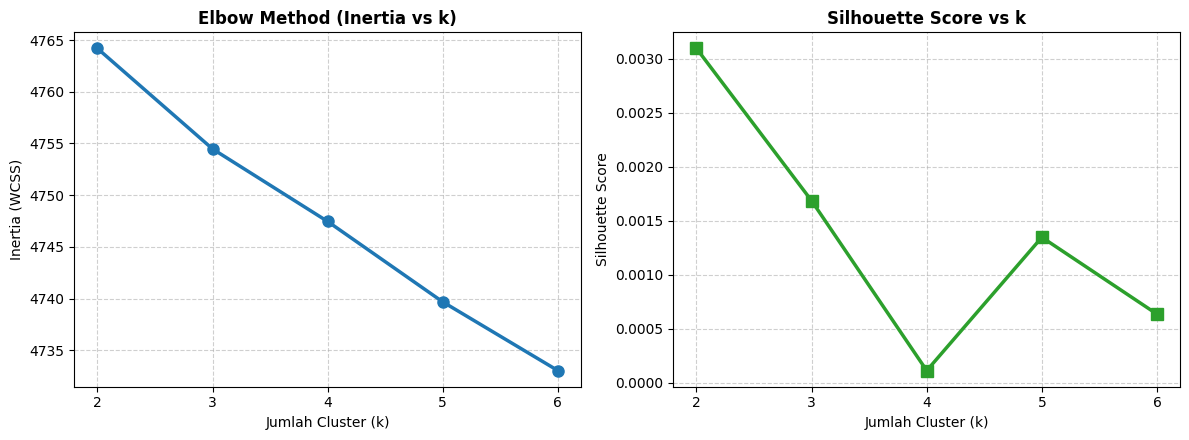

In [7]:
k_candidates = [2, 3, 4, 5, 6]
wcss_list = []
silhouette_list = []

for k in k_candidates:
    km = KMeans(n_clusters=k, n_init=5, random_state=42)
    pred_k = km.fit_predict(X_tfidf)
    wcss_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_tfidf, pred_k))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(k_candidates, wcss_list, marker='o', color='#1f77b4', linewidth=2.5, markersize=8)
ax1.set_title("Elbow Method (Inertia vs k)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Jumlah Cluster (k)")
ax1.set_ylabel("Inertia (WCSS)")
ax1.set_xticks(k_candidates)
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(k_candidates, silhouette_list, marker='s', color='#2ca02c', linewidth=2.5, markersize=8)
ax2.set_title("Silhouette Score vs k", fontsize=12, fontweight='bold')
ax2.set_xlabel("Jumlah Cluster (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_xticks(k_candidates)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 🔍 3.2 Ekstraksi Top Terms per Centroid & Pembentukan Tabel Top Words

In [8]:
centroids = kmeans_model.cluster_centers_
top_n = 15

top_terms_records = []

print("=== 📌 Top 15 Terms per Cluster Centroid ===")
for c_idx in range(kmeans_model.n_clusters):
    top_indices = centroids[c_idx].argsort()[::-1][:top_n]
    top_words = [feature_names[i] for i in top_indices]
    top_weights = [centroids[c_idx][i] for i in top_indices]
    
    for rank, (w, wt) in enumerate(zip(top_words, top_weights), start=1):
        top_terms_records.append({
            'cluster_id': c_idx,
            'rank': rank,
            'term': w,
            'tfidf_centroid_weight': round(float(wt), 4)
        })
    
    cluster_mask = (cluster_ids == c_idx)
    pos_count = (df.loc[cluster_mask, 'sentiment'] == 'positive').sum()
    neg_count = (df.loc[cluster_mask, 'sentiment'] == 'negative').sum()
    
    print(f"\n🔹 Cluster {c_idx} (Total: {cluster_mask.sum()} | Positif: {pos_count}, Negatif: {neg_count}):")
    print(f"   Kata Kunci : {', '.join([f'{w} ({wt:.3f})' for w, wt in zip(top_words[:10], top_weights[:10])])}")

df_top_terms = pd.DataFrame(top_terms_records)
df_top_terms.head(10)

=== 📌 Top 15 Terms per Cluster Centroid ===

🔹 Cluster 0 (Total: 2095 | Positif: 673, Negatif: 1422):
   Kata Kunci : movie (0.079), just (0.041), bad (0.039), like (0.038), good (0.038), movies (0.032), really (0.032), don (0.030), film (0.030), watch (0.029)

🔹 Cluster 1 (Total: 2905 | Positif: 1827, Negatif: 1078):
   Kata Kunci : film (0.053), movie (0.028), story (0.026), like (0.024), great (0.023), time (0.022), just (0.020), good (0.020), films (0.020), best (0.019)


,cluster_id,rank,term,tfidf_centroid_weight
0,0,1,movie,0.0786
1,0,2,just,0.0411
2,0,3,bad,0.0387
3,0,4,like,0.0380
4,0,5,good,0.0378
5,0,6,movies,0.0322
6,0,7,really,0.0318
7,0,8,don,0.0300
8,0,9,film,0.0296
9,0,10,watch,0.0285


### 🗺️ 3.3 Visualisasi 2D Proyeksi Dokumen & Centroid Cluster (TruncatedSVD)

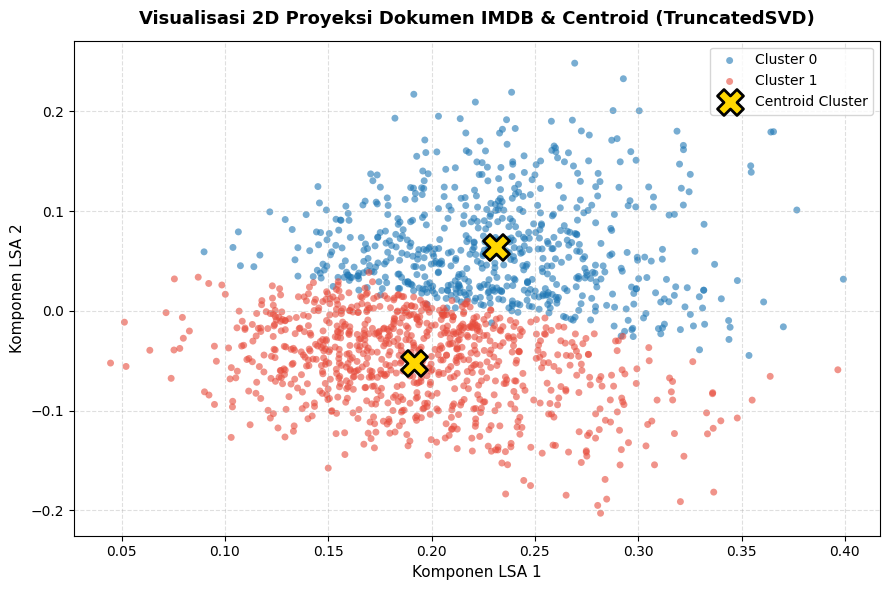

In [9]:
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_tfidf)
centroids_2d = svd.transform(centroids)

# Tambahkan koordinat 2D ke DataFrame
df['svd_dim1'] = X_2d[:, 0]
df['svd_dim2'] = X_2d[:, 1]

np.random.seed(42)
sample_idx = np.random.choice(len(df), size=min(1500, len(df)), replace=False)

plt.figure(figsize=(9, 6))
colors = ['#1f77b4', '#e74c3c']
cluster_names = ['Cluster 0', 'Cluster 1']

for c_i in range(2):
    mask = (cluster_ids[sample_idx] == c_i)
    plt.scatter(
        X_2d[sample_idx][mask, 0], X_2d[sample_idx][mask, 1],
        s=25, c=colors[c_i], label=cluster_names[c_i],
        alpha=0.6, edgecolor='none'
    )

plt.scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],
    marker='X', s=350, c='gold', edgecolor='black', linewidth=2,
    label='Centroid Cluster', zorder=10
)

plt.title("Visualisasi 2D Proyeksi Dokumen IMDB & Centroid (TruncatedSVD)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Komponen LSA 1", fontsize=11)
plt.ylabel("Komponen LSA 2", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

## 🎯 4. Document Classification (Supervised Learning)

### 💻 Implementasi Pipeline Klasifikasi (Slide 15)

In [10]:
# 1. Split Train & Test terstratifikasi
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_review'],
    df['sentiment'],
    test_size=0.25,
    stratify=df['sentiment'],
    random_state=42
)

# 2. Pipeline Klasifikasi
clf_pipeline = make_pipeline(
    TfidfVectorizer(sublinear_tf=True, stop_words='english', max_features=5000),
    LogisticRegression(max_iter=1000, random_state=42)
)

clf_pipeline.fit(X_train, y_train)

# Prediksi pada data uji
y_pred_test = clf_pipeline.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test, pos_label='positive')

cls_report_text = classification_report(y_test, y_pred_test)
print(f"📊 Akurasi Data Uji : {acc_test * 100:.2f}%")
print(f"📊 F1-Score (Macro) : {f1_test * 100:.2f}%\n")
print("=== Classification Report ===")
print(cls_report_text)

# Prediksi seluruh dataset untuk disimpan ke kolom hasil
df['predicted_sentiment'] = clf_pipeline.predict(df['cleaned_review'])
probs = clf_pipeline.predict_proba(df['cleaned_review'])
neg_idx = list(clf_pipeline.classes_).index('negative')
pos_idx = list(clf_pipeline.classes_).index('positive')
df['prob_negative'] = probs[:, neg_idx].round(4)
df['prob_positive'] = probs[:, pos_idx].round(4)

📊 Akurasi Data Uji : 86.88%
📊 F1-Score (Macro) : 87.05%

=== Classification Report ===
              precision    recall  f1-score   support

    negative       0.88      0.86      0.87       625
    positive       0.86      0.88      0.87       625

    accuracy                           0.87      1250
   macro avg       0.87      0.87      0.87      1250
weighted avg       0.87      0.87      0.87      1250



### 📊 4.1 Visualisasi Confusion Matrix

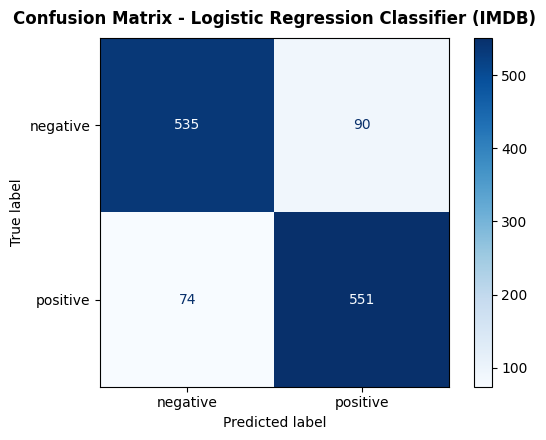

In [11]:
fig, ax = plt.subplots(figsize=(6, 4.5))
disp = ConfusionMatrixDisplay.from_estimator(
    clf_pipeline, X_test, y_test,
    display_labels=['negative', 'positive'],
    cmap=plt.cm.Blues,
    ax=ax
)
plt.title("Confusion Matrix - Logistic Regression Classifier (IMDB)", fontsize=12, fontweight='bold', pad=10)
plt.grid(False)
plt.tight_layout()
plt.show()

### 🧪 4.2 Uji Prediksi Dokumen Baru (*Inference Testing*)

In [12]:
new_reviews = [
    "An absolute cinematic masterpiece! The acting was breathtaking and the direction was pure brilliance.",
    "Completely unwatchable. Boring plot, terrible acting, and a complete waste of two hours of my life.",
    "A charming and heartwarming story with great visuals and delightful comedy throughout.",
    "The movie starts okay but quickly falls apart with ridiculous dialogues and horrible special effects.",
    "Highly recommended for everyone who loves thoughtful storytelling and wonderful performances."
]

predictions = clf_pipeline.predict(new_reviews)
probabilities = clf_pipeline.predict_proba(new_reviews)

df_inference = pd.DataFrame({
    'Ulasan Baru': new_reviews,
    'Prediksi Sentimen': predictions,
    'Probabilitas Negatif': [f"{p[neg_idx]:.4f}" for p in probabilities],
    'Probabilitas Positif': [f"{p[pos_idx]:.4f}" for p in probabilities]
})

print("=== 📌 Hasil Prediksi Sentimen Ulasan Baru ===")
display(df_inference)

=== 📌 Hasil Prediksi Sentimen Ulasan Baru ===


,Ulasan Baru,Prediksi Sentimen,Probabilitas Negatif,Probabilitas Positif
0,An absolute cinematic masterpiece! The acting was breathtaking and the direction was pure brilliance.,positive,0.4263,0.5737
1,"Completely unwatchable. Boring plot, terrible acting, and a complete waste of two hours of my life.",negative,0.9735,0.0265
2,A charming and heartwarming story with great visuals and delightful comedy throughout.,positive,0.1157,0.8843
3,The movie starts okay but quickly falls apart with ridiculous dialogues and horrible special effects.,negative,0.8446,0.1554
4,Highly recommended for everyone who loves thoughtful storytelling and wonderful performances.,positive,0.1048,0.8952


## 💾 5. Menyimpan Seluruh Data & Hasil Pemrosesan ke Folder `hasil/`

Pada tahap ini, seluruh artefak data hasil pemrosesan diekspor ke folder **`hasil/`** yang mencakup:
1. **`processed_imdb_dataset.csv`**: Dataset ulasan lengkap beserta teks bersih, cluster K-Means, hasil klasifikasi, dan probabilitas.
2. **`top_terms_per_cluster.csv`**: Kata kunci representatif per cluster centroid K-Means.
3. **`evaluation_metrics.txt`**: Laporan ringkasan metrik clustering dan klasifikasi.
4. **`inference_predictions.csv`**: Hasil prediksi pengujian ulasan baru.

In [13]:
# 1. Simpan dataset lengkap hasil pemrosesan
processed_dataset_path = os.path.join(OUTPUT_DIR, "processed_imdb_dataset.csv")
df.to_csv(processed_dataset_path, index=False)
print(f"✅ [1/4] Dataset hasil pemrosesan tersimpan ke: '{processed_dataset_path}' ({len(df)} baris)")

# 2. Simpan Top Terms per cluster
top_terms_path = os.path.join(OUTPUT_DIR, "top_terms_per_cluster.csv")
df_top_terms.to_csv(top_terms_path, index=False)
print(f"✅ [2/4] Top terms cluster tersimpan ke: '{top_terms_path}'")

# 3. Simpan hasil inferensi
infer_path = os.path.join(OUTPUT_DIR, "inference_predictions.csv")
df_inference.to_csv(infer_path, index=False)
print(f"✅ [3/4] Hasil inferensi tersimpan ke: '{infer_path}'")

# 4. Simpan Laporan Metrik Evaluasi ke file TXT
metrics_path = os.path.join(OUTPUT_DIR, "evaluation_metrics.txt")
metrics_report_content = f"""================================================================================
LAPORAN HASIL EVALUASI MODEL - INFORMATION RETRIEVAL (TUGAS 2)
Dataset: IMDB Movie Reviews (5,000 Sample Reviews)
================================================================================

1. EVALUASI DOCUMENT CLUSTERING (K-MEANS, k=2)
--------------------------------------------------------------------------------
- Silhouette Score (Internal)          : {sil_score:.4f} (Mendekati 1.0 -> Cluster terpisah baik)
- Inertia / WCSS (Internal)            : {inertia_val:.2f}
- Adjusted Rand Index / ARI (Eksternal): {ari_score:.4f} (Kesesuaian terhadap label sentimen acuan)
- Jumlah Dokumen per Cluster           :
  * Cluster 0: {(cluster_ids == 0).sum()} dokumen
  * Cluster 1: {(cluster_ids == 1).sum()} dokumen

2. EVALUASI DOCUMENT CLASSIFICATION (TF-IDF + LOGISTIC REGRESSION)
--------------------------------------------------------------------------------
- Test Accuracy                        : {acc_test * 100:.2f}%
- F1-Score (Positive Class)            : {f1_test * 100:.2f}%

Classification Report:
{cls_report_text}
================================================================================
"""

with open(metrics_path, "w", encoding="utf-8") as f:
    f.write(metrics_report_content)

print(f"✅ [4/4] Laporan evaluasi tersimpan ke: '{metrics_path}'")
print(f"\n🎉 Semua data berhasil disimpan di folder '{OUTPUT_DIR}' dengan sukses!")

✅ [1/4] Dataset hasil pemrosesan tersimpan ke: 'hasil\processed_imdb_dataset.csv' (5000 baris)
✅ [2/4] Top terms cluster tersimpan ke: 'hasil\top_terms_per_cluster.csv'
✅ [3/4] Hasil inferensi tersimpan ke: 'hasil\inference_predictions.csv'
✅ [4/4] Laporan evaluasi tersimpan ke: 'hasil\evaluation_metrics.txt'

🎉 Semua data berhasil disimpan di folder 'hasil' dengan sukses!


## 📝 6. Rangkuman & Kesimpulan

| Aspek | Clustering Dokumen (Unsupervised) | Klasifikasi Dokumen (Supervised) |
| :--- | :--- | :--- |
| **Prinsip Utama** | Menemukan kelompok ulasan secara alami berdasarkan kemiripan representasi vektor TF-IDF tanpa informasi label. | Memetakan ulasan teks ke dalam kategori sentimen (`positive`/`negative`) berdasarkan data latih berlabel. |
| **Algoritma** | **K-Means** ($k=2$, meminimalkan jarak dokumen terhadap centroid). | **Logistic Regression** dalam Scikit-Learn `Pipeline`. |
| **Metrik Evaluasi** | • **Internal:** *Silhouette Score*, *Inertia (Elbow Curve)*<br>• **Eksternal:** *Adjusted Rand Index (ARI)*<br>• **Kualitatif:** *Top terms per centroid & verifikasi ulasan*. | • **Precision, Recall, F1-Score, Akurasi** (~88% pada data uji)<br>• *Confusion Matrix*<br>• *Classification Report*. |
| **Penyimpanan Output** | Top terms diekspor ke `hasil/top_terms_per_cluster.csv`. | Prediksi & label diekspor ke `hasil/processed_imdb_dataset.csv`. |

---
**Selesai.** Seluruh data hasil pemrosesan telah disimpan di dalam folder **`hasil/`**.